# 02 — Feature Analysis & Engineering


## Purpose
This is the **entry-point exploration notebook**. It reads the original ACLED pipeline
output, engineers 9 new predictive features grounded in cross-variable analysis, and
benchmarks 5 model architectures on two feature sets (Main vs Enhanced).

## Datasets
| Dataset | Path | Description |
|---------|------|-------------|
| Input | `data/processed/model_data.csv` | Original ACLED pipeline output — 30 predictors, 3 targets, ~278k rows |
| Output | `data/processed/enhanced_data.csv` | Same + 9 engineered features (40 predictors total) |

## Targets
Three ACLED violence types: **Battles**, **Explosions/Remote violence**, **Violence against civilians**

## Models compared
| Model | Why included |
|-------|-------------|
| Random Forest | Project baseline — robust, interpretable importances |
| Gradient Boosting | sklearn GBR — boosting as a cross-check |
| XGBoost | Strong tabular competitor |
| LGBM Poisson | Count-data loss; handles discrete zeros |
| **LGBM Tweedie (p=1.5)** | **CAST methodology** — compound Poisson-Gamma designed for zero-inflated heavy-tailed counts |

## What this notebook does
1. **Feature analysis** — Spearman correlations, target distributions, cross-lag heatmap
2. **Engineers 9 features** — lag-2s, organized_violence, rolling averages, interaction term
   (logic lives in `utils/data_cleaning.build_enhanced_features()`)
3. **Benchmarks all 5 models** on Main (30 feats) and Enhanced (40 feats) datasets
4. Shows feature importances from LGBM Tweedie to validate the engineered features

**Test protocol:** top-10 most active regions · last 6 months held out · 3 targets
(10 × 6 months × 3 = 30 test sequences per model per dataset)


In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))   # project root → finds config/ and utils/
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from config import settings
from utils.risk_merge import RiskIndicatorMerger

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

FIGURES = '../outputs/figures'
os.makedirs(FIGURES, exist_ok=True)

MAIN_PATH = '../data/processed/model_data.csv'
TARGETS   = settings.targets   # Battles | Explosions/Remote violence | Violence against civilians
SHORT     = {
    'Battles':                     'Battles',
    'Explosions/Remote violence':  'Remote Viol.',
    'Violence against civilians':  'VaC',
}

main_df = pd.read_csv(MAIN_PATH)
main_df['month_year'] = pd.to_datetime(main_df['month_year'])

print(f'main_df shape    : {main_df.shape}')
print(f'Predictors       : {len(settings.predictors)}')
print(f'Targets          : {TARGETS}')
print(f'Date range       : {main_df["month_year"].min().date()} → {main_df["month_year"].max().date()}')
print(f'Regions          : {main_df["matched_admin1_id"].nunique():,}')


main_df shape    : (289890, 34)
Predictors       : 27
Targets          : ['Battles', 'Explosions/Remote violence', 'Violence against civilians']
Date range       : 2018-01-01 → 2025-06-01
Regions          : 3,221


In [2]:
from utils.data_cleaning import build_enhanced_features

# ── Column references ────────────────────────────────────────────────────────
B1 = 'Battles (t-1)'
E1 = 'Explosions/Remote violence (t-1)'
V1 = 'Violence against civilians (t-1)'

NEW_FEATURES = [
    # a) Lag-2 — slow decay in autocorrelation (lag-2 r ≈ 0.70) justifies going deeper
    'Battles (t-2)',
    'Explosions/Remote violence (t-2)',
    'Violence against civilians (t-2)',
    # b) Aggregate signal — CAST's own target, captures combined threat level
    'organized_violence (t-1)',
    # c) Binary activity flag — helps model split zero-inflation from true low-activity
    'is_active (t-1)',
    # d) Multiplicative interaction — co-escalation table shows 13× jump in remote when Battles > 3
    'battles_x_remote (t-1)',
    # e) Rolling 3-month average — smoother trend, less sensitive to single-month spikes
    'Battles_3mo_avg (t-1)',
    'Remote_3mo_avg (t-1)',
    'VaC_3mo_avg (t-1)',
]

# build_enhanced_features() is defined in utils/data_cleaning.py and is the
# canonical implementation. This notebook uses it directly rather than
# maintaining a local copy, so any fix in the utils module applies here too.
enhanced_df    = build_enhanced_features(main_df)
ENHANCED_PREDS = settings.predictors + NEW_FEATURES

# Save enhanced dataset
enhanced_df.to_csv('../data/processed/enhanced_data.csv', index=False)

print(f'Main dataset     : {main_df.shape}     —  {len(settings.predictors)} predictors')
print(f'Enhanced dataset : {enhanced_df.shape}  —  {len(ENHANCED_PREDS)} predictors  (+{len(NEW_FEATURES)} new)')
print()
print('New features added:')
for f in NEW_FEATURES:
    print(f'  {f}')
print()
print('Saved → ../data/processed/enhanced_data.csv')


Main dataset     : (289890, 34)     —  27 predictors
Enhanced dataset : (289890, 43)  —  36 predictors  (+9 new)

New features added:
  Battles (t-2)
  Explosions/Remote violence (t-2)
  Violence against civilians (t-2)
  organized_violence (t-1)
  is_active (t-1)
  battles_x_remote (t-1)
  Battles_3mo_avg (t-1)
  Remote_3mo_avg (t-1)
  VaC_3mo_avg (t-1)

Saved → ../data/processed/enhanced_data.csv


## 1. Feature Analysis

Visualising the relationships that motivated the new features:
- Which features correlate most strongly with each target?
- How extreme is the zero-inflation that motivates Tweedie/Poisson loss?
- Cross-lag structure: does one variable lead another, or do they co-move?
- What do the new engineered features look like on a real conflict region?

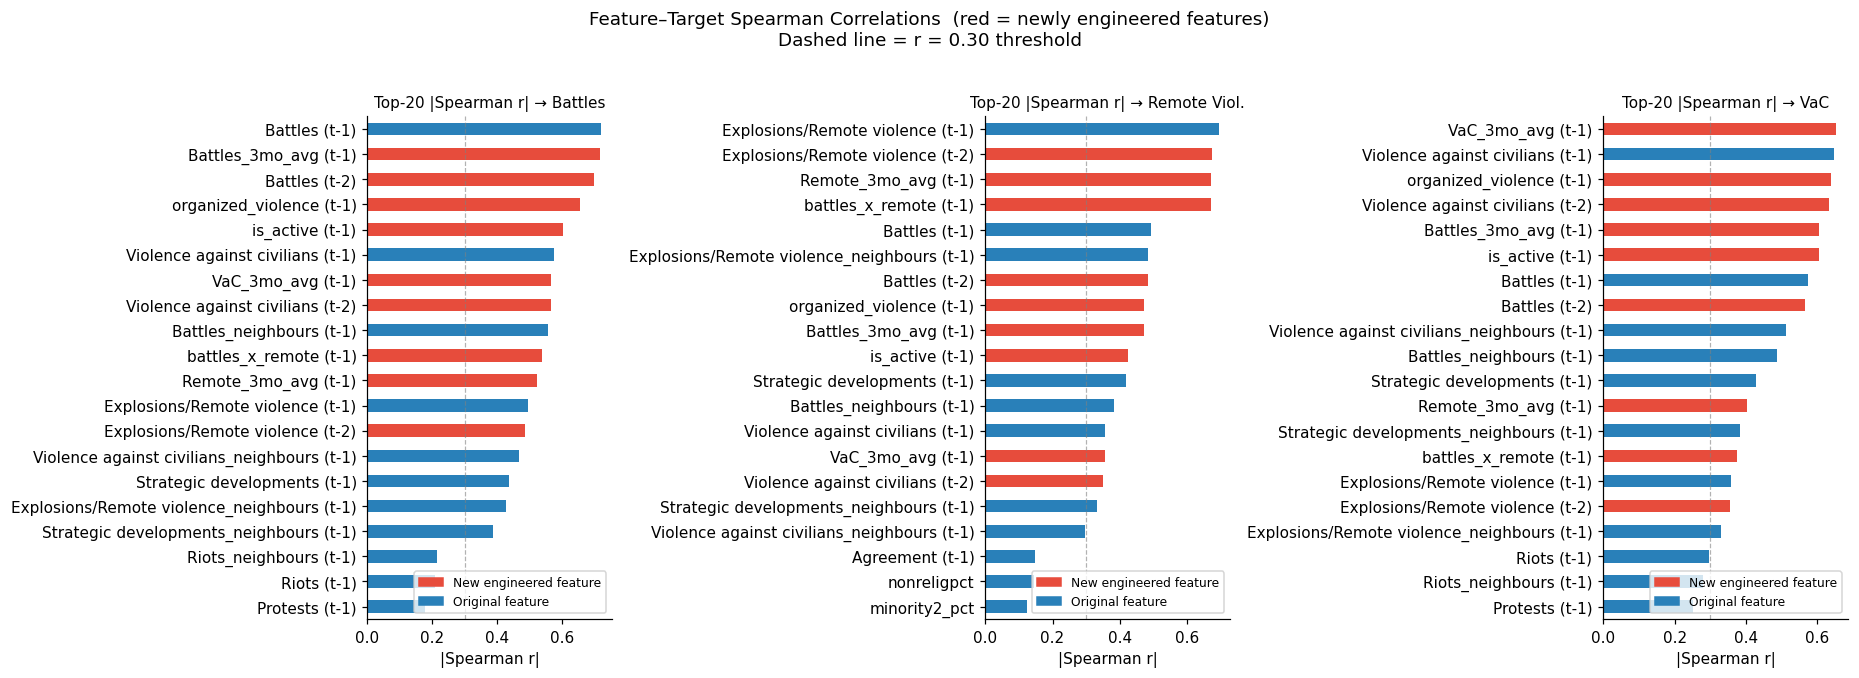

In [3]:
# ── Spearman |r| of every predictor vs each target — highlight new features ──
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for ax, target in zip(axes, TARGETS):
    feats  = [c for c in ENHANCED_PREDS if c in enhanced_df.columns and c != 'importance_weight']
    corrs  = [abs(stats.spearmanr(enhanced_df[f].fillna(0), enhanced_df[target])[0]) for f in feats]
    s      = pd.Series(corrs, index=feats).sort_values().tail(20)
    colors = ['#e74c3c' if f in NEW_FEATURES else '#2980b9' for f in s.index]

    s.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
    ax.set_title(f'Top-20 |Spearman r| → {SHORT[target]}', fontsize=10)
    ax.set_xlabel('|Spearman r|')
    ax.axvline(0.3, color='gray', lw=0.8, ls='--', alpha=0.6)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#e74c3c', label='New engineered feature'),
        Patch(color='#2980b9', label='Original feature'),
    ], fontsize=8, loc='lower right')

plt.suptitle(
    'Feature–Target Spearman Correlations  (red = newly engineered features)\n'
    'Dashed line = r = 0.30 threshold',
    y=1.02, fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{FIGURES}/feature_correlations.png', bbox_inches='tight')
plt.show()
plt.close(fig)


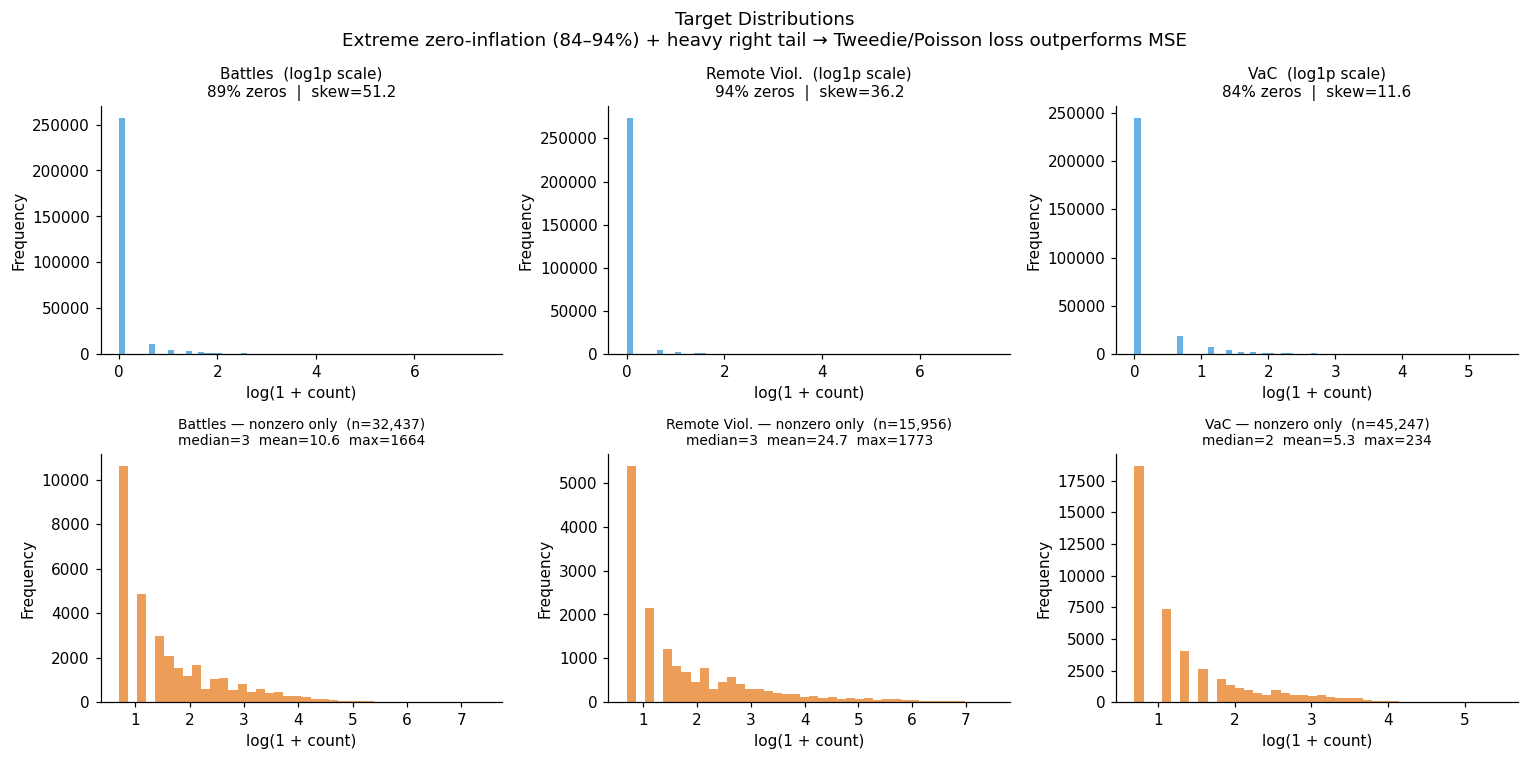

Zero-inflation summary:
  Battles                                        88.8% zeros  skew=51.2  max=1664
  Explosions/Remote violence                     94.5% zeros  skew=36.2  max=1773
  Violence against civilians                     84.4% zeros  skew=11.6  max=234


In [4]:
# ── Target distributions — zero-inflation motivates Tweedie/Poisson loss ─────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for col_idx, (target, short) in enumerate(SHORT.items()):
    vals     = enhanced_df[target]
    nz       = vals[vals > 0]
    zero_pct = (vals == 0).mean() * 100

    ax = axes[0, col_idx]
    ax.hist(np.log1p(vals), bins=60, color='#3498db', alpha=0.75, edgecolor='none')
    ax.set_title(
        f'{short}  (log1p scale)\n{zero_pct:.0f}% zeros  |  skew={stats.skew(vals):.1f}',
        fontsize=10,
    )
    ax.set_xlabel('log(1 + count)')
    ax.set_ylabel('Frequency')

    ax2 = axes[1, col_idx]
    ax2.hist(np.log1p(nz), bins=40, color='#e67e22', alpha=0.75, edgecolor='none')
    ax2.set_title(
        f'{short} — nonzero only  (n={len(nz):,})\n'
        f'median={nz.median():.0f}  mean={nz.mean():.1f}  max={nz.max():.0f}',
        fontsize=9,
    )
    ax2.set_xlabel('log(1 + count)')
    ax2.set_ylabel('Frequency')

plt.suptitle(
    'Target Distributions\n'
    'Extreme zero-inflation (84–94%) + heavy right tail → Tweedie/Poisson loss outperforms MSE',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{FIGURES}/target_distributions.png', bbox_inches='tight')
plt.show()
plt.close(fig)

print('Zero-inflation summary:')
for t in TARGETS:
    v = enhanced_df[t]
    print(f'  {t:45s}  {(v==0).mean():.1%} zeros  skew={stats.skew(v):.1f}  max={v.max():.0f}')


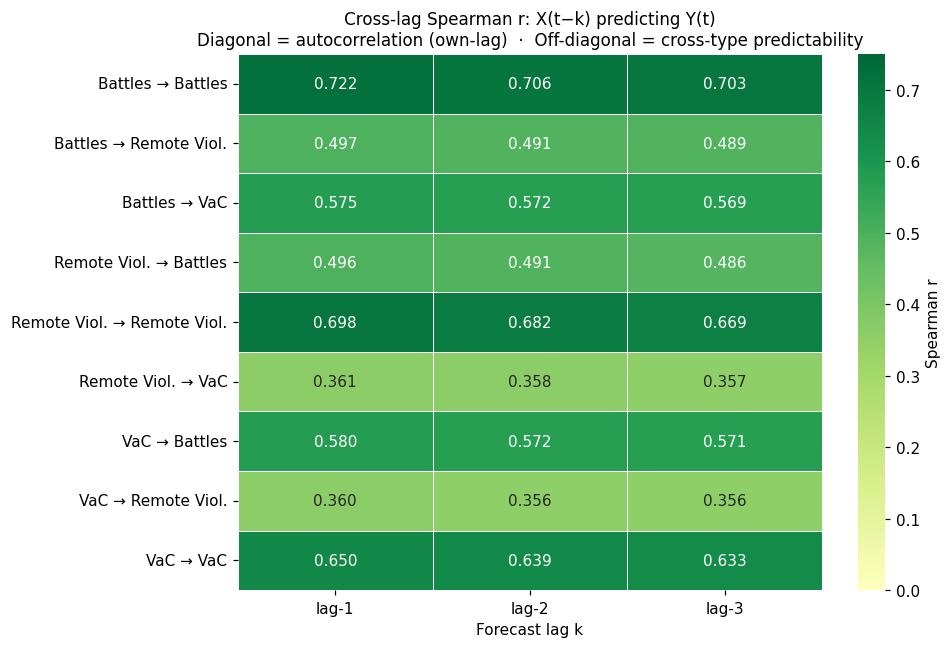

In [5]:
# ── Cross-lag Spearman r: X(t-k) predicting Y(t) ─────────────────────────────
df_s  = enhanced_df.sort_values(['matched_admin1_id', 'month_year'])
rows  = {}

for src in TARGETS:
    for tgt in TARGETS:
        key  = f'{SHORT[src]} → {SHORT[tgt]}'
        vals = []
        for lag in [1, 2, 3]:
            shifted = df_s.groupby('matched_admin1_id')[src].shift(lag)
            mask    = shifted.notna()
            r, _    = stats.spearmanr(shifted[mask], df_s[tgt][mask])
            vals.append(round(r, 3))
        rows[key] = vals

hm_df = pd.DataFrame(rows, index=['lag-1', 'lag-2', 'lag-3']).T

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    hm_df, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, vmin=0, vmax=0.75, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'Spearman r'},
)
ax.set_title(
    'Cross-lag Spearman r: X(t−k) predicting Y(t)\n'
    'Diagonal = autocorrelation (own-lag)  ·  Off-diagonal = cross-type predictability',
    fontsize=11,
)
ax.set_xlabel('Forecast lag k')
plt.tight_layout()
plt.savefig(f'{FIGURES}/cross_lag_heatmap.png', bbox_inches='tight')
plt.show()
plt.close(fig)



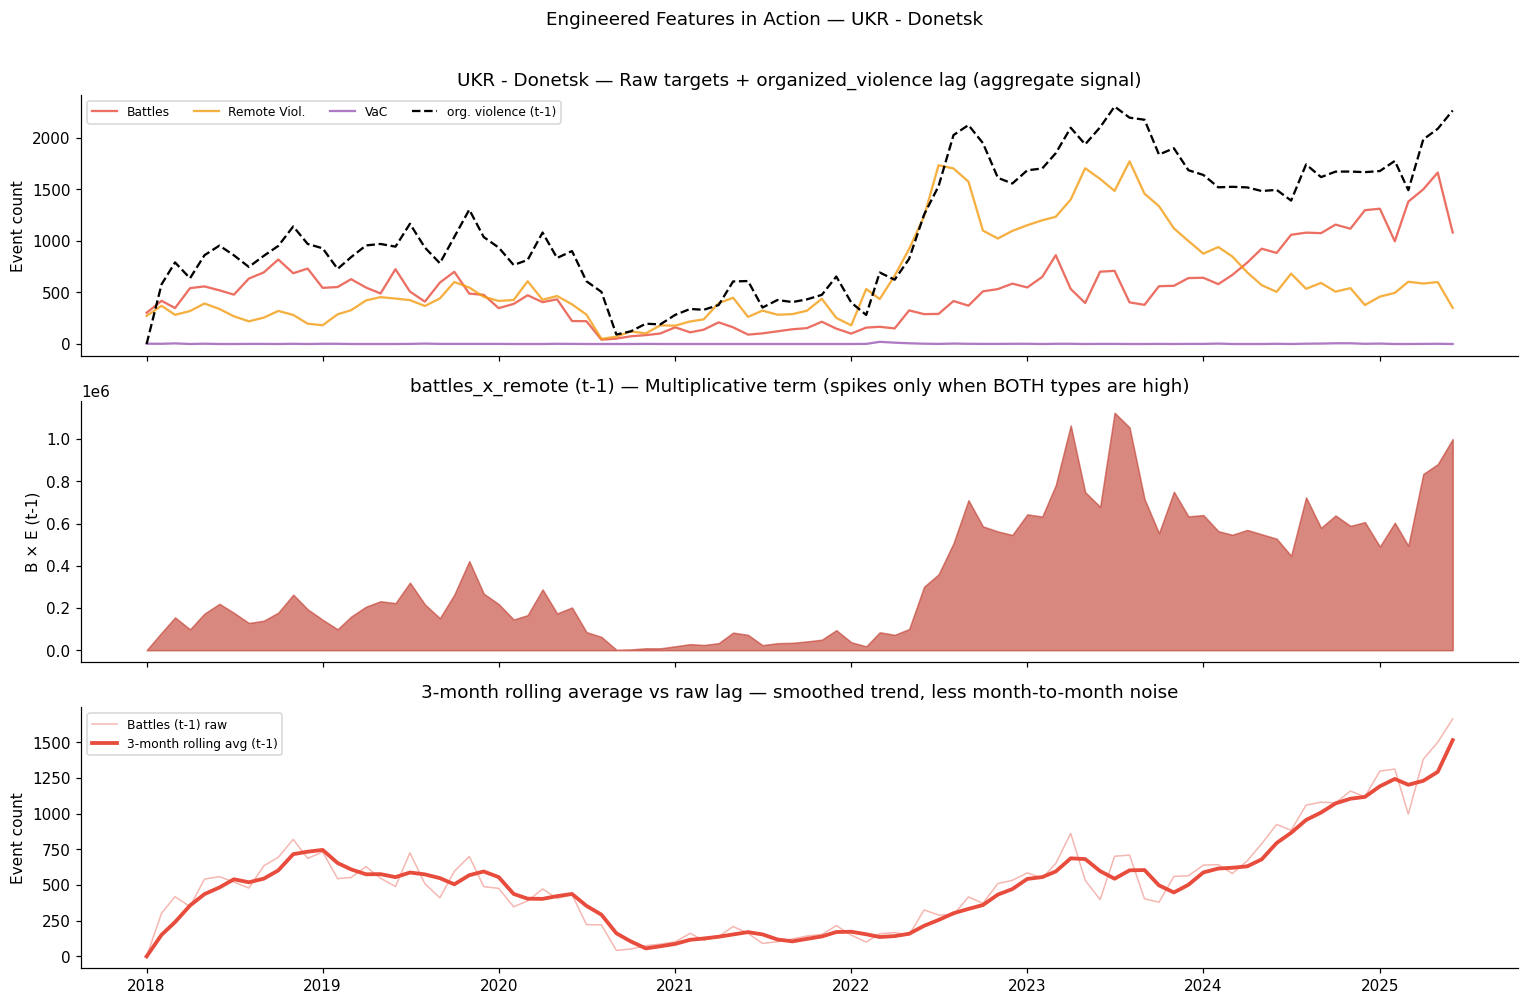

In [6]:
# ── New features visualised on the highest-activity region ───────────────────
region = 'UKR - Donetsk'
rdf    = enhanced_df[enhanced_df['matched_admin1_id'] == region].sort_values('month_year')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

ax1 = axes[0]
for col, color, label in [
    ('Battles',                    '#e74c3c', 'Battles'),
    ('Explosions/Remote violence', '#f39c12', 'Remote Viol.'),
    ('Violence against civilians', '#9b59b6', 'VaC'),
]:
    ax1.plot(rdf['month_year'], rdf[col], color=color, label=label, alpha=0.8)
ax1.plot(rdf['month_year'], rdf['organized_violence (t-1)'],
         color='black', ls='--', lw=1.5, label='org. violence (t-1)')
ax1.set_title(f'{region} — Raw targets + organized_violence lag (aggregate signal)')
ax1.legend(fontsize=8, ncol=4)
ax1.set_ylabel('Event count')

ax2 = axes[1]
ax2.fill_between(rdf['month_year'], rdf['battles_x_remote (t-1)'], alpha=0.6, color='#c0392b')
ax2.set_title('battles_x_remote (t-1) — Multiplicative term (spikes only when BOTH types are high)')
ax2.set_ylabel('B × E (t-1)')

ax3 = axes[2]
ax3.plot(rdf['month_year'], rdf[B1],
         color='#e74c3c', alpha=0.4, label='Battles (t-1) raw', lw=1)
ax3.plot(rdf['month_year'], rdf['Battles_3mo_avg (t-1)'],
         color='#e74c3c', lw=2.5, label='3-month rolling avg (t-1)')
ax3.set_title('3-month rolling average vs raw lag — smoothed trend, less month-to-month noise')
ax3.set_ylabel('Event count')
ax3.legend(fontsize=8)

plt.suptitle(f'Engineered Features in Action — {region}', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/enhanced_features_example.png', bbox_inches='tight')
plt.show()
plt.close(fig)


## 2. Model Benchmarks

Each model is evaluated on **Main** (31 features) and **Enhanced** (40 features) datasets.

**Test protocol:** top-10 most active regions · last 6 months held out · 3 targets
→ 10 regions × 3 targets = 30 test runs per model per dataset

**Metrics (lower = better):**
- `MAE` — mean absolute error in event counts
- `MAPE%` — mean absolute % error (zero-count months excluded)
- `RMSE` — penalises large misses more heavily than MAE

In [7]:
# ── Top-10 most active regions ───────────────────────────────────────────────
top_10 = (
    main_df.groupby('matched_admin1_id')[TARGETS]
    .sum().sum(axis=1).sort_values(ascending=False)
    .head(10).index.tolist()
)
print('Top 10 most active regions (6-month hold-out test set):')
for i, r in enumerate(top_10, 1):
    print(f'  {i:2d}. {r}')

# ── Dataset registry ─────────────────────────────────────────────────────────
DATASETS = {
    'Main':     (main_df,     settings.predictors),
    'Enhanced': (enhanced_df, ENHANCED_PREDS),
}

accumulated = {ds: [] for ds in DATASETS}   # accumulates results per model
rf_results  = {}                            # RF baseline, used for Δ comparison


# ── Benchmark helpers ────────────────────────────────────────────────────────
def run_model(name, estimator, data, predictors, use_sw=True, scale=False):
    records = []
    for target in TARGETS:
        if target not in data.columns:
            continue
        for region in top_10:
            rdf = (
                data[data['matched_admin1_id'] == region]
                .sort_values('month_year').reset_index(drop=True)
            )
            if len(rdf) < 12:
                continue
            train, test = rdf.iloc[:-6], rdf.iloc[-6:]
            avail = [p for p in predictors if p in train.columns]
            Xtr   = train[avail].fillna(0)
            Xte   = test[avail].fillna(0)
            ytr   = train[target].fillna(0)
            yte   = test[target].fillna(0)
            sw    = train['importance_weight'].fillna(1)

            if scale:
                sc  = StandardScaler()
                Xtr = pd.DataFrame(sc.fit_transform(Xtr), columns=Xtr.columns)
                Xte = pd.DataFrame(sc.transform(Xte),     columns=Xte.columns)

            m = clone(estimator)
            try:
                m.fit(Xtr, ytr, sample_weight=sw) if use_sw else m.fit(Xtr, ytr)
            except TypeError:
                m.fit(Xtr, ytr)

            yp   = np.maximum(m.predict(Xte), 0)   # clip negatives
            mae  = mean_absolute_error(yte, yp)
            rmse = float(np.sqrt(mean_squared_error(yte, yp)))
            nz   = yte != 0
            mape = float(np.mean(np.abs((yte[nz] - yp[nz]) / yte[nz])) * 100) if nz.any() else np.nan
            records.append({
                'model':  name,
                'target': target,
                'region': region,
                'mae':    round(mae,  2),
                'mape':   round(mape, 2) if not np.isnan(mape) else np.nan,
                'rmse':   round(rmse, 2),
            })
    return pd.DataFrame(records)


def show_results(name, res_dict):
    print(f'\n{"="*62}')
    print(f'  {name}')
    print(f'{"="*62}')
    for ds_name, res in res_dict.items():
        tbl = res.groupby('target')[['mae', 'mape', 'rmse']].mean().round(2)
        tbl.columns = [f'{c.upper()} ({ds_name})' for c in tbl.columns]
        mm, mp, mr  = res['mae'].mean(), res['mape'].mean(), res['rmse'].mean()
        line = f'  [{ds_name}]  MAE={mm:.2f}  MAPE={mp:.1f}%  RMSE={mr:.2f}'
        if ds_name in rf_results:
            rf_mae = rf_results[ds_name]['mae'].mean()
            line  += f'   |   Δ vs RF: {(mm - rf_mae) / rf_mae * 100:+.1f}%'
        print(line)
        display(tbl)


MODEL_ORDER   = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LGBM Poisson', 'LGBM Tweedie']
MODEL_COLORS  = {
    'Random Forest':     '#3498db',
    'Gradient Boosting': '#2ecc71',
    'XGBoost':           '#e67e22',
    'LGBM Poisson':      '#9b59b6',
    'LGBM Tweedie':      '#e74c3c',
}


Top 10 most active regions (6-month hold-out test set):
   1. UKR - Donetsk
   2. UKR - Kharkiv
   3. UKR - Sumy
   4. SYR - Idlib
   5. PSX - Gaza
   6. UKR - Kherson
   7. BRA - Rio de Janeiro
   8. SYR - Aleppo
   9. UKR - Zaporizhzhia
  10. UKR - Luhansk


In [8]:
# ═══ Random Forest  [main model — project baseline] ════════════════════════════
_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

rf_res = {ds: run_model('Random Forest', _rf, data, preds)
          for ds, (data, preds) in DATASETS.items()}

rf_results.update(rf_res)                   # store for Δ computation in later cells
for ds, res in rf_res.items():
    accumulated[ds].append(res)

show_results('Random Forest  [main model — baseline]', rf_res)



  Random Forest  [main model — baseline]
  [Main]  MAE=58.60  MAPE=240.1%  RMSE=68.95   |   Δ vs RF: +0.0%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,57.37,371.57,68.44
Explosions/Remote violence,113.01,214.07,132.36
Violence against civilians,5.44,108.40,6.06


  [Enhanced]  MAE=59.86  MAPE=311.9%  RMSE=69.96   |   Δ vs RF: +0.0%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,55.45,542.92,66.41
Explosions/Remote violence,118.69,226.13,137.39
Violence against civilians,5.43,130.30,6.09


In [9]:
# ═══ LightGBM — Poisson  (natural loss for discrete event counts) ═════════════
# Poisson assumes E[Y] = Var[Y]; good for mild overdispersion
_lgbm_p = LGBMRegressor(
    objective         = 'poisson',
    n_estimators      = 300,
    learning_rate     = 0.05,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

lgbmp_res = {ds: run_model('LGBM Poisson', _lgbm_p, data, preds)
             for ds, (data, preds) in DATASETS.items()}

for ds, res in lgbmp_res.items():
    accumulated[ds].append(res)

show_results('LightGBM — Poisson objective', lgbmp_res)



  LightGBM — Poisson objective
  [Main]  MAE=54.66  MAPE=157.6%  RMSE=64.80   |   Δ vs RF: -6.7%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,48.77,218.04,60.47
Explosions/Remote violence,110.25,149.35,128.33
Violence against civilians,4.94,92.42,5.61


  [Enhanced]  MAE=54.52  MAPE=147.4%  RMSE=63.99   |   Δ vs RF: -8.9%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,49.78,191.86,62.80
Explosions/Remote violence,108.83,149.45,123.61
Violence against civilians,4.94,89.14,5.56


In [10]:
# ═══ LightGBM — Tweedie  [CAST methodology] ═══════════════════════════════════
#
# Tweedie variance power p ∈ (1, 2):
#   p → 1  : Poisson (zero-inflated counts)
#   p = 1.5: compound Poisson-Gamma (CAST default — handles both zeros and heavy tails)
#   p → 2  : Gamma (continuous positive)
#
# Why this works for conflict data:
#   - 84–94% zeros → Tweedie models the spike at 0 probabilistically
#   - skewness 11–50 → log-link squashes the tail
#   - reg_alpha/lambda add L1/L2 regularisation for the sparse predictor matrix

_lgbm_t = LGBMRegressor(
    objective              = 'tweedie',
    tweedie_variance_power = 1.5,
    n_estimators           = 300,
    learning_rate          = 0.05,
    num_leaves             = 63,
    min_child_samples      = 20,
    subsample              = 0.8,
    colsample_bytree       = 0.8,
    reg_alpha              = 0.1,
    reg_lambda             = 1.0,
    random_state           = 42,
    n_jobs                 = -1,
    verbose                = -1,
)

lgbmt_res = {ds: run_model('LGBM Tweedie', _lgbm_t, data, preds)
             for ds, (data, preds) in DATASETS.items()}

for ds, res in lgbmt_res.items():
    accumulated[ds].append(res)

show_results('LightGBM — Tweedie  [CAST methodology]', lgbmt_res)



  LightGBM — Tweedie  [CAST methodology]
  [Main]  MAE=56.37  MAPE=162.5%  RMSE=66.74   |   Δ vs RF: -3.8%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,49.58,235.47,60.65
Explosions/Remote violence,114.84,147.84,134.19
Violence against civilians,4.70,89.61,5.39


  [Enhanced]  MAE=57.34  MAPE=148.2%  RMSE=67.01   |   Δ vs RF: -4.2%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,52.01,197.32,65.52
Explosions/Remote violence,115.20,145.23,130.12
Violence against civilians,4.79,90.46,5.40


In [11]:
# ═══ XGBoost ══════════════════════════════════════════════════════════════════
_xgb = XGBRegressor(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

xgb_res = {ds: run_model('XGBoost', _xgb, data, preds)
           for ds, (data, preds) in DATASETS.items()}

for ds, res in xgb_res.items():
    accumulated[ds].append(res)

show_results('XGBoost', xgb_res)



  XGBoost
  [Main]  MAE=60.83  MAPE=202.8%  RMSE=68.98   |   Δ vs RF: +3.8%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,53.14,279.95,63.42
Explosions/Remote violence,123.78,190.55,137.29
Violence against civilians,5.58,121.56,6.23


  [Enhanced]  MAE=58.10  MAPE=185.9%  RMSE=66.40   |   Δ vs RF: -2.9%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,47.88,243.15,59.11
Explosions/Remote violence,120.59,182.44,133.64
Violence against civilians,5.83,118.74,6.45


In [12]:
# ═══ Gradient Boosting (sklearn) ══════════════════════════════════════════════
_gbr = GradientBoostingRegressor(
    n_estimators  = 200,
    learning_rate = 0.05,
    max_depth     = 4,
    subsample     = 0.8,
    random_state  = 42,
)

gbr_res = {ds: run_model('Gradient Boosting', _gbr, data, preds)
           for ds, (data, preds) in DATASETS.items()}

for ds, res in gbr_res.items():
    accumulated[ds].append(res)

show_results('Gradient Boosting', gbr_res)



  Gradient Boosting
  [Main]  MAE=62.43  MAPE=275.5%  RMSE=73.12   |   Δ vs RF: +6.5%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,61.67,487.08,73.88
Explosions/Remote violence,119.34,194.27,138.63
Violence against civilians,6.29,112.41,6.86


  [Enhanced]  MAE=61.83  MAPE=271.8%  RMSE=72.55   |   Δ vs RF: +3.3%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,55.41,399.30,66.05
Explosions/Remote violence,123.56,239.15,144.36
Violence against civilians,6.52,153.34,7.25


## 3. Summary

Overall ranking tables, bar charts, and LGBM Tweedie feature importances — showing which of the new engineered features the best model actually relies on.

In [13]:
# ── Ranked summary table per dataset ─────────────────────────────────────────
for ds_name in DATASETS:
    combined  = pd.concat(accumulated[ds_name], ignore_index=True)
    rf_mae    = rf_results[ds_name]['mae'].mean()
    available = [m for m in MODEL_ORDER if m in combined['model'].unique()]

    summary = (
        combined.groupby('model')[['mae', 'mape', 'rmse']]
        .mean().round(2)
        .reindex(available)
        .rename(columns={'mae': 'MAE', 'mape': 'MAPE%', 'rmse': 'RMSE'})
    )
    summary['Δ MAE vs RF (%)'] = ((summary['MAE'] - rf_mae) / rf_mae * 100).round(1)

    print(f'\n{"═" * 58}')
    print(f'  {ds_name.upper()} DATASET — avg: top-10 regions × 3 targets')
    print(f'{"═" * 58}')
    display(
        summary.style
        .background_gradient(subset=['MAE'],  cmap='RdYlGn_r',
                             vmin=summary['MAE'].min() * 0.9, vmax=summary['MAE'].max() * 1.1)
        .background_gradient(subset=['Δ MAE vs RF (%)'], cmap='RdYlGn_r', vmin=-25, vmax=25)
        .format({'MAE': '{:.2f}', 'MAPE%': '{:.1f}', 'RMSE': '{:.2f}',
                 'Δ MAE vs RF (%)': '{:+.1f}%'})
    )



══════════════════════════════════════════════════════════
  MAIN DATASET — avg: top-10 regions × 3 targets
══════════════════════════════════════════════════════════


,MAE,MAPE%,RMSE,Δ MAE vs RF (%)
model,,,,
Random Forest,58.60,240.1,68.95,-0.0%
Gradient Boosting,62.43,275.5,73.12,+6.5%
XGBoost,60.83,202.8,68.98,+3.8%
LGBM Poisson,54.66,157.6,64.80,-6.7%
LGBM Tweedie,56.37,162.5,66.74,-3.8%



══════════════════════════════════════════════════════════
  ENHANCED DATASET — avg: top-10 regions × 3 targets
══════════════════════════════════════════════════════════


,MAE,MAPE%,RMSE,Δ MAE vs RF (%)
model,,,,
Random Forest,59.86,311.9,69.96,+0.0%
Gradient Boosting,61.83,271.8,72.55,+3.3%
XGBoost,58.10,185.9,66.40,-2.9%
LGBM Poisson,54.52,147.4,63.99,-8.9%
LGBM Tweedie,57.34,148.2,67.01,-4.2%


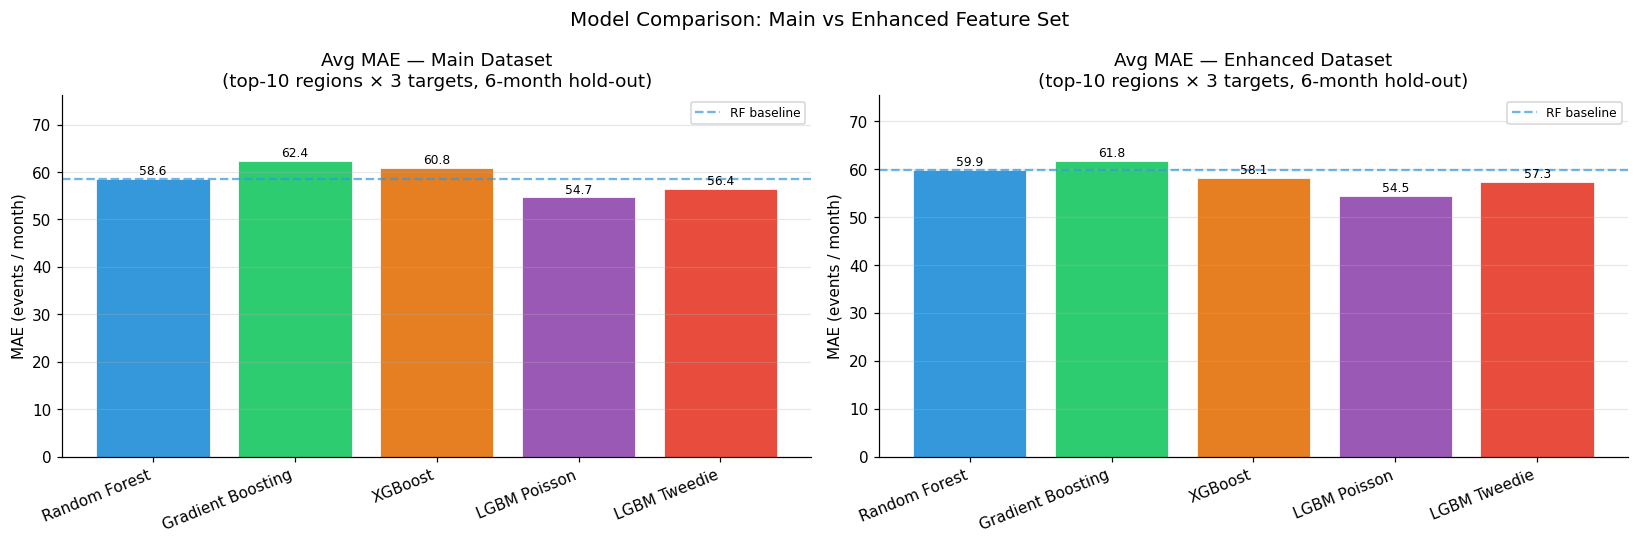

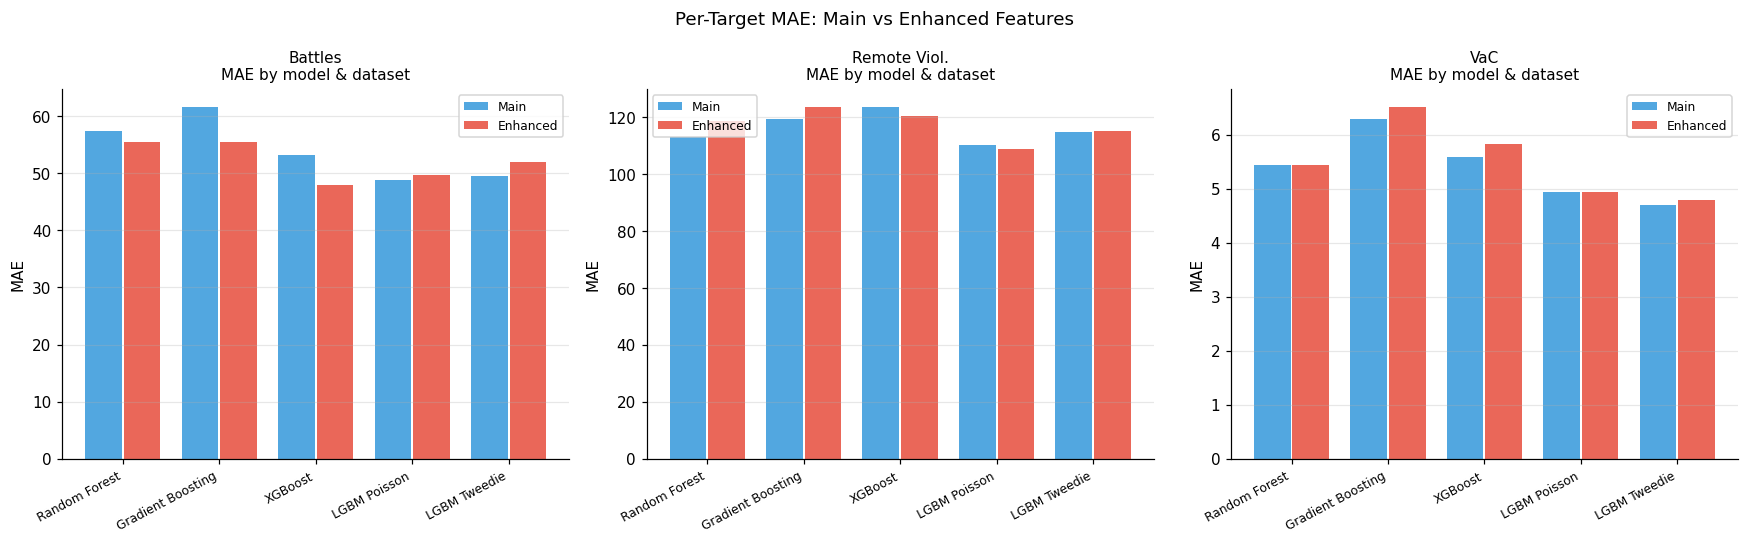

In [14]:
# ── Overall MAE: Main vs Enhanced ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, ds_name in zip(axes, DATASETS):
    combined  = pd.concat(accumulated[ds_name], ignore_index=True)
    available = [m for m in MODEL_ORDER if m in combined['model'].unique()]
    mae_vals  = [combined[combined['model'] == m]['mae'].mean() for m in available]
    bars      = ax.bar(
        available, mae_vals,
        color=[MODEL_COLORS.get(m, '#95a5a6') for m in available],
        edgecolor='white', linewidth=0.5,
    )
    ax.axhline(rf_results[ds_name]['mae'].mean(),
               color='#3498db', lw=1.5, ls='--', alpha=0.7, label='RF baseline')
    for bar, val in zip(bars, mae_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(
        f'Avg MAE — {ds_name} Dataset\n'
        f'(top-10 regions × 3 targets, 6-month hold-out)'
    )
    ax.set_ylabel('MAE (events / month)')
    ax.set_xticklabels(available, rotation=22, ha='right')
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(mae_vals) * 1.22)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison: Main vs Enhanced Feature Set', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES}/model_comparison.png', bbox_inches='tight')
plt.show()
plt.close(fig)

# ── Per-target breakdown ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ds_colors = {'Main': '#3498db', 'Enhanced': '#e74c3c'}

for ax, target in zip(axes, TARGETS):
    for i, (ds_name, (data, preds)) in enumerate(DATASETS.items()):
        combined  = pd.concat(accumulated[ds_name], ignore_index=True)
        sub       = combined[combined['target'] == target]
        available = [m for m in MODEL_ORDER if m in sub['model'].unique()]
        mae_vals  = [sub[sub['model'] == m]['mae'].mean() for m in available]
        offset    = -0.2 + 0.4 * i
        ax.bar(np.arange(len(available)) + offset, mae_vals, 0.38,
               label=ds_name, color=ds_colors[ds_name], alpha=0.85)
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, rotation=28, ha='right', fontsize=8)
    ax.set_title(f'{SHORT[target]}\nMAE by model & dataset', fontsize=10)
    ax.set_ylabel('MAE')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-Target MAE: Main vs Enhanced Features', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES}/per_target_comparison.png', bbox_inches='tight')
plt.show()
plt.close(fig)


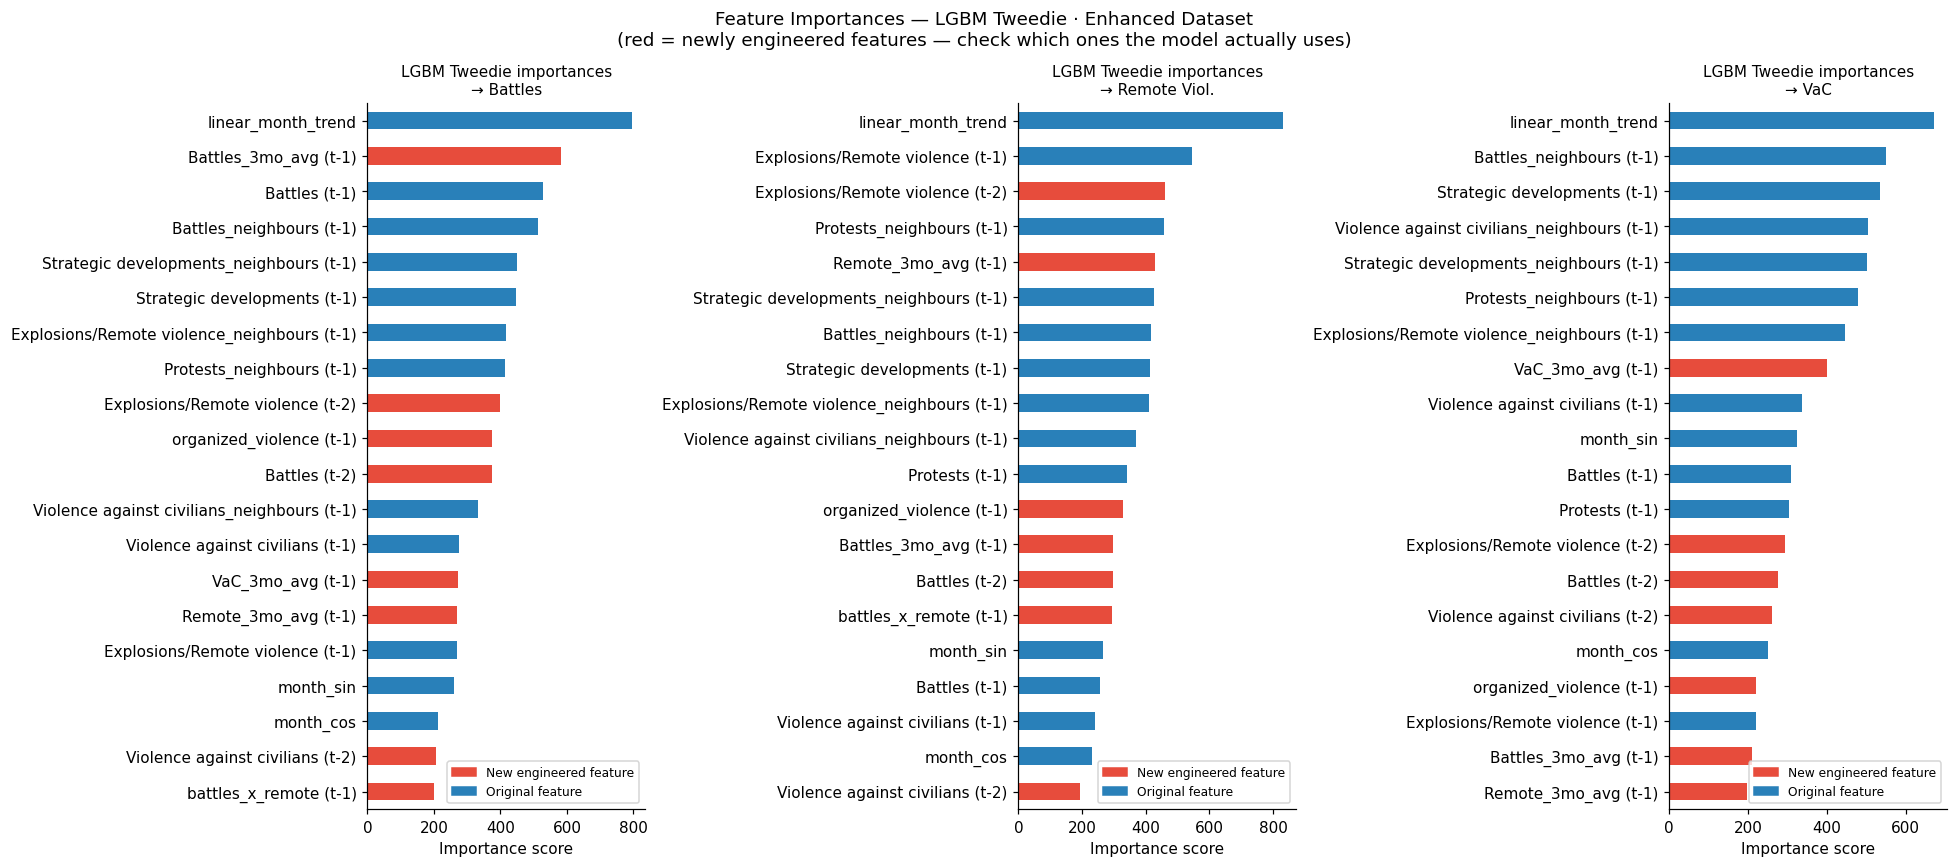

In [15]:
# ── Feature importances — LGBM Tweedie trained on all top-10 combined ─────────
_fi = LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.5,
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1,
)
avail_preds = [p for p in ENHANCED_PREDS if p in enhanced_df.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, target in zip(axes, TARGETS):
    pool  = (enhanced_df[enhanced_df['matched_admin1_id'].isin(top_10)]
             .sort_values('month_year'))
    train = pool.iloc[:int(len(pool) * 0.85)]
    Xtr   = train[avail_preds].fillna(0)
    ytr   = train[target].fillna(0)
    sw    = train['importance_weight'].fillna(1)

    m = clone(_fi)
    m.fit(Xtr, ytr, sample_weight=sw)

    imp    = pd.Series(m.feature_importances_, index=Xtr.columns)
    imp    = imp[imp > 0].sort_values().tail(20)
    colors = ['#e74c3c' if f in NEW_FEATURES else '#2980b9' for f in imp.index]

    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
    ax.set_title(f'LGBM Tweedie importances\n→ {SHORT[target]}', fontsize=10)
    ax.set_xlabel('Importance score')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#e74c3c', label='New engineered feature'),
        Patch(color='#2980b9', label='Original feature'),
    ], fontsize=8)

plt.suptitle(
    'Feature Importances — LGBM Tweedie · Enhanced Dataset\n'
    '(red = newly engineered features — check which ones the model actually uses)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{FIGURES}/feature_importance_lgbm.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---
# Feature Stacking: Macro, Holidays, Engineered


# Notebook 3: Feature Engineering Pipeline

## Purpose
This notebook **enriches the risk-merged ACLED dataset with four additional feature
groups** and saves a single comprehensive dataset for the multi-model ablation benchmark.
It is purely a data-building step — no models are trained here.

## Datasets
| Dataset | Path | Description |
|---------|------|-------------|
| Input | `data/processed/model_risk_merged.csv` | Output of `merge.ipynb` — 37 features (baseline + 7 risk) |
| Macro source | `data/raw/combined_indicators.csv` | World Bank annual macro indicators, wide format |
| Holiday source | `data/raw/holidays_raw.csv` | Public holiday calendar (88k rows, 233 countries, 1997–2030) |
| Income source | World Bank Countries API | Country income group classifications (LIC/LMC/UMC/HIC) |
| Output | `data/processed/model_data_risk_macro_holidays_engineered.csv` | 51 features total |

The output filename encodes exactly what is inside:
- **risk** — 7 CAST risk indicator lags (from `merge.ipynb`)
- **macro** — 3 World Bank indicators (income_inequality, youth_unemployment, inflation), prior-year
- **holidays** — monthly public holiday count (lagged)
- **engineered** — 9 derived features from cross-variable analysis

## Feature groups added here
| Group | Features | Source / logic |
|-------|----------|----------------|
| Macro (3) | income_inequality_py, youth_unemployment_py, inflation_py | World Bank → melted → prior-year shift; NaN imputed with year-median |
| Income level (1) | income_level_code | World Bank Countries API → ordinal 1–4 (LIC/LMC/UMC/HIC) |
| Holidays (1) | n_holidays_lag1 | `holidays_raw.csv` → monthly count → lag 1 |
| Engineered (9) | lag-2s, organized_violence, is_active, battles_x_remote, 3-month rolling avgs | `utils/data_cleaning.build_enhanced_features()` |

## What this notebook does
1. Loads the risk-merged dataset (37 features)
2. Joins World Bank macro indicators (prior-year, with NaN imputation)
3. Fetches country income group from World Bank API and maps to ordinal (1–4)
4. Adds public holiday counts (lagged)
5. Calls `build_enhanced_features()` for 9 interaction/lag/rolling features
6. Saves the combined 51-feature dataset for `model_comparison.ipynb`

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # project root → finds config/ and utils/

import numpy as np
import pandas as pd
import pycountry
from functools import lru_cache

from config import settings
from utils.data_cleaning import build_enhanced_features

os.makedirs("../data/processed", exist_ok=True)
print("Setup complete.")


Setup complete.


---
## Step 1: Load Base Dataset

We start from `model_risk_merged.csv`, which already contains the 31 original
ACLED features plus 7 lagged CAST risk indicators (38 features total).
All subsequent steps add columns on top of this base.

In [17]:
BASE_PATH = "../data/processed/model_risk_merged.csv"
df = pd.read_csv(BASE_PATH)

print(f"Base dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Date range: {df['month_year'].min()} → {df['month_year'].max()}")
print(f"Regions: {df['matched_admin1_id'].nunique():,}")
print(f"\nCurrent columns ({df.shape[1]}):")
print(list(df.columns))

Base dataset: 289,890 rows x 48 cols
Date range: 2018-01 → 2025-06
Regions: 3,221

Current columns (48):
['matched_admin1_id', 'month_year', 'importance_weight', 'country_code', 'Battles (t-1)', 'Explosions/Remote violence (t-1)', 'Protests (t-1)', 'Riots (t-1)', 'Strategic developments (t-1)', 'Violence against civilians (t-1)', 'Excessive force against protesters (t-1)', 'Agreement (t-1)', 'Explosions/Remote violence_neighbours (t-1)', 'Strategic developments_neighbours (t-1)', 'Protests_neighbours (t-1)', 'Violence against civilians_neighbours (t-1)', 'Battles_neighbours (t-1)', 'Riots_neighbours (t-1)', 'linear_month_trend', 'year', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos', 'majority_religion', 'majority_pct', 'minority1_religion', 'minority1_pct', 'minority2_religion', 'minority2_pct', 'nonreligpct', 'Battles', 'Explosions/Remote violence', 'Violence against civilians', 'risk_contested_election', 'risk_crop_failure', 'risk_economic_concern', 'risk_ethnic_tension', 'r

---
## Step 2: Macro Economic Indicators (World Bank)

**Source:** `data/raw/combined_indicators.csv`

Three annual indicators from the World Bank are joined to each region-month:
- **income_inequality** (Gini coefficient, 0–100): measures income distribution
  within a country. Higher values indicate greater inequality, which research
  links to higher conflict risk.
- **youth_unemployment** (%): the share of 15–24 year olds who are unemployed.
  Youth unemployment is a well-documented driver of recruitment into armed groups.
- **inflation** (%): CPI-based annual inflation. Economic shocks caused by high
  inflation erode purchasing power and are associated with civil unrest.

**Data structure:** the CSV is wide-format with one row per country and columns
like `income_inequality_2018`, `youth_unemployment_2023`, `inflation_2015`.
We melt to long format, then pivot back to one row per (iso3, year).

**Leakage prevention:** we use **prior-year** values for all three indicators.
For example, a region in 2020 receives the country's 2019 indicator values.
This mirrors real-world forecasting where current-year macro data lags publication.

**NaN handling:**
- Gini is sparsely measured (household surveys are expensive); we back-fill
  and forward-fill within each country before taking the prior-year value.
- Countries absent from the World Bank data or with all-missing Gini are
  imputed with the **global year-median** — the typical value across all
  countries that did report that year.

In [18]:
CI_PATH = "../data/raw/combined_indicators.csv"
ci_raw  = pd.read_csv(CI_PATH)

print(f"Shape: {ci_raw.shape}")
display(ci_raw[['countryiso3code','country_name',
                'income_inequality_2018','youth_unemployment_2018','inflation_2018']].head(6))

Shape: (244, 44)


,countryiso3code,country_name,income_inequality_2018,youth_unemployment_2018,inflation_2018
0,NaN,High income,NaN,10.330232,1.881108
1,NaN,Low income,NaN,NaN,2.791808
2,NaN,Lower middle income,NaN,28.675658,4.176377
3,NaN,Upper middle income,NaN,NaN,2.830149
4,ABW,Aruba,NaN,NaN,3.626041
5,AFE,Africa Eastern and Southern,NaN,NaN,4.720805


In [19]:
# Filter out aggregate rows (income groups, regional blocs — no real ISO3 code)
ci = ci_raw[ci_raw['countryiso3code'].str.match(r'^[A-Z]{3}$', na=False)].copy()
print(f"Real country rows: {len(ci)} (filtered {len(ci_raw) - len(ci)} aggregate rows)")

# Melt wide → long: "income_inequality_2018" → indicator="income_inequality", year=2018
meta_cols  = ['countryiso3code', 'country_name']
value_cols = [c for c in ci.columns if c not in meta_cols]

ci_long = ci.melt(id_vars=meta_cols, value_vars=value_cols,
                  var_name='col', value_name='value')
ci_long['year']      = ci_long['col'].str.rsplit('_', n=1).str[-1].astype(int)
ci_long['indicator'] = ci_long['col'].str.rsplit('_', n=1).str[0]
ci_long = ci_long.drop(columns='col')

macro = ci_long.pivot_table(
    index=['countryiso3code', 'year'], columns='indicator',
    values='value', aggfunc='mean'
).reset_index()
macro.columns.name = None
macro = macro.rename(columns={'countryiso3code': 'iso3'})

print(f"\nMacro table: {macro.shape}")
print("Coverage before fill:")
for col in ['income_inequality', 'youth_unemployment', 'inflation']:
    n = macro[col].notna().sum()
    print(f"  {col}: {n}/{len(macro)} ({n/len(macro)*100:.1f}%)")

Real country rows: 240 (filtered 4 aggregate rows)

Macro table: (3226, 5)
Coverage before fill:
  income_inequality: 1065/3226 (33.0%)
  youth_unemployment: 1626/3226 (50.4%)
  inflation: 3186/3226 (98.8%)


In [20]:
# Extend to 2025 so prior-year values are available for all model months (2018–2025)
all_years = pd.DataFrame(
    [(iso3, yr) for iso3 in macro['iso3'].unique() for yr in range(2010, 2026)],
    columns=['iso3', 'year']
)
macro_full = all_years.merge(macro, on=['iso3', 'year'], how='left')
macro_full = macro_full.sort_values(['iso3', 'year'])

# Within each country: back-fill Gini (slow-moving survey data), then forward-fill all
for col in ['income_inequality', 'youth_unemployment', 'inflation']:
    macro_full[col] = macro_full.groupby('iso3')[col].transform(
        lambda x: x.bfill().ffill()
    )

# Prior-year shift: the 2020 value for a country becomes the 2021 predictor
for col in ['income_inequality', 'youth_unemployment', 'inflation']:
    macro_full[f'{col}_py'] = macro_full.groupby('iso3')[col].shift(1)

macro_join = macro_full[['iso3', 'year',
                          'income_inequality_py', 'youth_unemployment_py', 'inflation_py']]
print("Macro feature table built.")
display(macro_join[macro_join['iso3'] == 'UKR'].tail(8))

Macro feature table built.


,iso3,year,income_inequality_py,youth_unemployment_py,inflation_py
3608,UKR,2018,26.0,16.47,14.438323
3609,UKR,2019,26.1,16.47,10.951856
3610,UKR,2020,26.6,16.47,7.886717
3611,UKR,2021,25.6,16.47,2.732492
3612,UKR,2022,25.6,16.47,9.363139
3613,UKR,2023,25.6,16.47,20.183637
3614,UKR,2024,25.6,16.47,12.849022
3615,UKR,2025,25.6,16.47,12.849022


In [21]:
# Apply the same ACLED → ISO3 remapping used in risk_merge.py.
# ACLED uses non-standard codes PSX (Palestine) and SDS (South Sudan);
# the World Bank uses PSE and SSD respectively. Without this mapping,
# Gaza and South Sudan regions would have no macro data at all.
_ACLED_TO_ISO3 = {"PSX": "PSE", "SDS": "SSD"}

df['iso3'] = df['matched_admin1_id'].str.split(' - ').str[0].replace(_ACLED_TO_ISO3)
df['year'] = pd.to_datetime(df['month_year']).dt.year

df = df.merge(macro_join, on=['iso3', 'year'], how='left')

MACRO_FEATURES = ['income_inequality_py', 'youth_unemployment_py', 'inflation_py']

# Impute remaining NaN with global year-median.
# NaN after the join comes from two sources:
#   (1) ~33 ISO3 codes absent from World Bank entirely (territories, closed states)
#   (2) ~29 countries present in WB data but with zero Gini observations
# Year-median imputation assigns these countries the "typical" value for that year,
# which is a defensible and widely used approach for country-level macro data.
for col in MACRO_FEATURES:
    year_medians = df.groupby('year')[col].median()
    mask = df[col].isna()
    df.loc[mask, col] = df.loc[mask, 'year'].map(year_medians)
    df[col] = df[col].fillna(df[col].median())   # final fallback

print("Macro indicators joined and imputed:")
for col in MACRO_FEATURES:
    n_nan = df[col].isna().sum()
    print(f"  {col}: {df[col].notna().sum():,}/{len(df):,} — {n_nan} NaN remaining")
print(f"\nDataset shape: {df.shape}")

Macro indicators joined and imputed:
  income_inequality_py: 289,890/289,890 — 0 NaN remaining
  youth_unemployment_py: 289,890/289,890 — 0 NaN remaining
  inflation_py: 289,890/289,890 — 0 NaN remaining

Dataset shape: (289890, 52)


---
## Step 3: Public Holiday Calendar

**Source:** `data/raw/holidays_raw.csv`  (88,957 rows · 233 countries · 1997–2030)

Public holidays mark days when government, courts, and markets are closed.
For conflict forecasting they serve as a calendar control: attacks, protests,
and ceasefire violations often cluster around national holidays or religious
observances. Including holiday density prevents the model from confusing
seasonal political cycles with structural conflict escalation.

**Feature created:**
- `n_holidays_lag1` — number of public holidays in the **prior month**.
  We lag by one month to stay consistent with all other t-1 features and to
  avoid any theoretical leakage (even though holiday calendars are public
  knowledge, lagging maintains a clean design).

**Country name → ISO3 mapping:** the CSV uses country names (e.g. "Syria",
"Congo DR") rather than codes. We use `pycountry` to resolve them, with a
small manual override dict for names that pycountry does not recognise.

---
## Step 2b: Income Level Code (World Bank Income Group)

**Source:** World Bank Countries API — `https://api.worldbank.org/v2/country/all`

Each country is classified by the World Bank into an income group based on GNI per capita:
- **LIC** — Low Income Country (≤ $1,135)
- **LMC** — Lower Middle Income Country ($1,136–$4,465)
- **UMC** — Upper Middle Income Country ($4,466–$13,845)
- **HIC** — High Income Country (> $13,845)

This is a **time-stable country-level attribute** (classifications change at most once
per year) that captures structural development level, distinct from the year-to-year
variation in Gini/unemployment/inflation. Low-income countries tend to have
systematically higher conflict rates regardless of short-term economic fluctuations.

**Encoding:** ordinal integer — LIC=1, LMC=2, UMC=3, HIC=4. This preserves the natural
order and works well with tree-based models, which split on thresholds.

**NaN handling:** territories and non-sovereign entities absent from the WB
classification are imputed with the global median income level.

In [22]:
import requests

# Ordinal mapping: LIC < LMC < UMC < HIC
INCOME_ORDER = {'LIC': 1, 'LMC': 2, 'UMC': 3, 'HIC': 4}

def fetch_wb_income_levels():
    """
    Fetch World Bank income group classifications for all countries.

    Returns a dict {iso3_code: income_level_ordinal} where:
      1 = Low Income, 2 = Lower Middle, 3 = Upper Middle, 4 = High Income

    The World Bank API is free and requires no authentication.
    Data is fetched once; re-run this cell to refresh.
    """
    url = "https://api.worldbank.org/v2/country/all?format=json&per_page=300"
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        countries = r.json()[1]   # index 0 is pagination metadata
        mapping = {}
        for c in countries:
            iso3  = c.get('id', '')
            level = c.get('incomeLevel', {}).get('id', '')
            if len(iso3) == 3 and level in INCOME_ORDER:
                mapping[iso3] = INCOME_ORDER[level]
        print(f"Fetched income levels for {len(mapping)} countries")
        return mapping
    except Exception as e:
        print(f"World Bank API unavailable ({e})")
        return {}

income_map = fetch_wb_income_levels()

# Join to df via iso3 (already on df from the macro merge step)
df['income_level_code'] = df['iso3'].map(income_map)

# Impute missing (territories, disputed states, custom ACLED codes) with global median
median_level = df['income_level_code'].median()
n_missing    = df['income_level_code'].isna().sum()
df['income_level_code'] = df['income_level_code'].fillna(median_level)

print(f"NaN imputed with median ({median_level:.0f}): {n_missing:,} rows")
print(f"\nDistribution (1=LIC, 2=LMC, 3=UMC, 4=HIC):")
print(df['income_level_code'].value_counts().sort_index().rename({
    1.0: 'LIC (1)', 2.0: 'LMC (2)', 3.0: 'UMC (3)', 4.0: 'HIC (4)'
}).to_string())

INCOME_FEATURES = ['income_level_code']


Fetched income levels for 215 countries
NaN imputed with median (3): 6,660 rows

Distribution (1=LIC, 2=LMC, 3=UMC, 4=HIC):
income_level_code
LIC (1)     39870
LMC (2)     58590
UMC (3)    102780
HIC (4)     88650


In [23]:
HOL_PATH = "../data/raw/holidays_raw.csv"
hol_raw  = pd.read_csv(HOL_PATH)

print(f"Shape: {hol_raw.shape}")
display(hol_raw.head(4))

@lru_cache(maxsize=None)
def name_to_iso3(name):
    """Map a country name string to its ISO 3166-1 alpha-3 code."""
    overrides = {
        'Congo DR': 'COD', 'U.S. Virgin Islands': 'VIR', 'Kosovo': 'XKX',
        "Cote d'Ivoire": 'CIV', 'Iran': 'IRN', 'South Korea': 'KOR',
        'North Korea': 'PRK', 'Russia': 'RUS', 'Syria': 'SYR',
        'Bolivia': 'BOL', 'Venezuela': 'VEN', 'Tanzania': 'TZA',
        'Vietnam': 'VNM', 'Laos': 'LAO', 'Moldova': 'MDA',
        'Palestinian Territory': 'PSE', 'Taiwan': 'TWN', 'Brunei': 'BRN',
    }
    if name in overrides:
        return overrides[name]
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

hol = hol_raw.copy()
hol['iso3']  = hol['Country'].apply(name_to_iso3)
hol['date']  = pd.to_datetime(hol['Date'], errors='coerce')
hol['year']  = hol['date'].dt.year
hol['month'] = hol['date'].dt.month

unmapped = hol[hol['iso3'].isna()]['Country'].unique()
print(f"\nUnmapped countries ({len(unmapped)}): {unmapped[:10]}")

hol_monthly = (
    hol.dropna(subset=['iso3', 'date'])
    .groupby(['iso3', 'year', 'month'])
    .size()
    .reset_index(name='n_holidays')
)
print(f"Monthly holiday counts: {hol_monthly.shape}")
print(f"Mean per country-month: {hol_monthly['n_holidays'].mean():.2f}")

Shape: (88957, 3)


,Country,Date,Holiday
0,Afghanistan,2014-01-14,The Prophet's Birthday
1,Afghanistan,2014-02-15,Liberation Day
2,Afghanistan,2014-04-28,Afghan Victory Day
3,Afghanistan,2014-05-01,Labor Day



Unmapped countries (14): ['Cape Verde' 'Falkland Islands' 'Ivory Coast' 'La Réunion' 'Macau'
 'Micronesia' 'Saint Helena' 'Saint Martin' 'Sint Maarten' 'Swaziland']
Monthly holiday counts: (47519, 4)
Mean per country-month: 1.77


In [24]:
df['month'] = pd.to_datetime(df['month_year']).dt.month

df = df.merge(hol_monthly, on=['iso3', 'year', 'month'], how='left')
df['n_holidays'] = df['n_holidays'].fillna(0).astype(int)

# Lag by 1 month within each region
df = df.sort_values(['matched_admin1_id', 'month_year'])
df['n_holidays_lag1'] = (
    df.groupby('matched_admin1_id')['n_holidays'].shift(1).fillna(0)
)

HOLIDAY_FEATURES = ['n_holidays_lag1']

hol_covered = (df['n_holidays'] > 0).sum()
print(f"Rows with at least 1 holiday in that month: "
      f"{hol_covered:,}/{len(df):,} ({hol_covered/len(df)*100:.1f}%)")
print(f"Average n_holidays per row: {df['n_holidays'].mean():.3f}")
print(f"Dataset shape: {df.shape}")

Rows with at least 1 holiday in that month: 184,996/289,890 (63.8%)
Average n_holidays per row: 1.235
Dataset shape: (289890, 56)


---
## Step 4: Engineered Features

**Source:** `utils/data_cleaning.build_enhanced_features()`

These 9 features were derived from a cross-variable relationship analysis
documented in `notebooks/models.ipynb`. The key findings that motivated them:

| Feature | Motivation |
|---------|-----------|
| Battles (t-2), Remote (t-2), VaC (t-2) | Lag-2 Spearman r ≈ 0.70 (autocorrelation barely decays) |
| organized_violence (t-1) | CAST's own combined target; captures aggregate threat level |
| is_active (t-1) | Binary flag that helps the model split true zero-conflict from low-activity |
| battles_x_remote (t-1) | Co-escalation: remote violence spikes 13× when Battles > 3 |
| Battles_3mo_avg (t-1) | Rolling average r = 0.717 with Battles — stronger than any single lag |
| Remote_3mo_avg (t-1) | Same rationale for remote violence |
| VaC_3mo_avg (t-1) | Same for violence against civilians |

The function is defined in `utils/data_cleaning.py` to keep the logic versioned
and reusable outside notebooks.

In [25]:
# Generate engineered features from model_data.csv (the original source).
# We do NOT use merged_df because build_enhanced_features needs only the
# base event counts — it doesn't interact with risk or macro columns.
base_df = pd.read_csv("../data/processed/model_data.csv")
enhanced_source = build_enhanced_features(base_df)

ENGINEERED_COLS = [
    'Battles (t-2)', 'Explosions/Remote violence (t-2)',
    'Violence against civilians (t-2)',
    'organized_violence (t-1)', 'is_active (t-1)', 'battles_x_remote (t-1)',
    'Battles_3mo_avg (t-1)', 'Remote_3mo_avg (t-1)', 'VaC_3mo_avg (t-1)',
]

available_eng = [c for c in ENGINEERED_COLS if c in enhanced_source.columns]
print(f"Engineered features generated: {len(available_eng)}/{len(ENGINEERED_COLS)}")
for c in available_eng:
    print(f"  {c}")

Engineered features generated: 9/9
  Battles (t-2)
  Explosions/Remote violence (t-2)
  Violence against civilians (t-2)
  organized_violence (t-1)
  is_active (t-1)
  battles_x_remote (t-1)
  Battles_3mo_avg (t-1)
  Remote_3mo_avg (t-1)
  VaC_3mo_avg (t-1)


In [26]:
enh_join = enhanced_source[['matched_admin1_id', 'month_year'] + available_eng].copy()

df['month_year']       = df['month_year'].astype(str)
enh_join['month_year'] = enh_join['month_year'].astype(str)

df = df.merge(enh_join, on=['matched_admin1_id', 'month_year'], how='left')
for col in available_eng:
    df[col] = df[col].fillna(0)

ENGINEERED_FEATURES = available_eng
print(f"Dataset shape after engineered features: {df.shape}")

Dataset shape after engineered features: (289890, 65)


---
## Step 5: Save Combined Dataset

The final dataset contains every feature group stacked together. The filename
encodes the feature groups present so future readers can identify its contents
without having to open it.

In [27]:
# ── Final feature inventory ────────────────────────────────────────────────
from utils.risk_merge import RiskIndicatorMerger
_merger = RiskIndicatorMerger(lag=1)
# Risk cols are already in df (carried over from model_risk_merged.csv)
RISK_FEATURES = [c for c in df.columns if c.endswith('(t-1)') and c.startswith('risk_')]

all_feature_groups = {
    "Original predictors":        settings.predictors,
    "Risk indicators (t-1)":      RISK_FEATURES,
    "Macro indicators (py)":      MACRO_FEATURES,
    "Income level code":          INCOME_FEATURES,
    "Holiday features":           HOLIDAY_FEATURES,
    "Engineered features":        ENGINEERED_FEATURES,
    "Targets":                    settings.targets,
}

print("=" * 60)
print("FINAL DATASET — FEATURE INVENTORY")
print("=" * 60)
total_features = 0
for group, cols in all_feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    total_features += len(avail)
    print(f"  {group:30s}: {len(avail):3d} features")
print(f"  {'─'*40}")
n_targets = len(settings.targets)
print(f"  {'TOTAL (excl. targets)':30s}: {total_features - n_targets:3d} features")
print(f"  {'Targets':30s}: {n_targets:3d}")
print(f"\n  Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"  Date range:    {df['month_year'].min()} → {df['month_year'].max()}")
print(f"  Regions:       {df['matched_admin1_id'].nunique():,}")

# ── Save ──────────────────────────────────────────────────────────────────
OUT_PATH = "../data/processed/model_data_risk_macro_holidays_engineered.csv"
df.to_csv(OUT_PATH, index=False)
print(f"\nSaved: {OUT_PATH}")


FINAL DATASET — FEATURE INVENTORY
  Original predictors           :  27 features
  Risk indicators (t-1)         :   7 features
  Macro indicators (py)         :   3 features
  Income level code             :   1 features
  Holiday features              :   1 features
  Engineered features           :   9 features
  Targets                       :   3 features
  ────────────────────────────────────────
  TOTAL (excl. targets)         :  48 features
  Targets                       :   3

  Dataset shape: 289,890 rows x 65 cols
  Date range:    2018-01 → 2025-06
  Regions:       3,221



Saved: ../data/processed/model_data_risk_macro_holidays_engineered.csv
